# Hierarchical Product Launch — `MultiGoal` sequential decomposition

A Tier 3 tutorial that stages a SaaS product launch as three dependent sub-goals and lets LangGOAP chain them in a single `graph.invoke` call. The spotlight is the `MultiGoal` abstraction in `sequential` mode: you declare the stages once, the observer runs them in order, and per-stage world state hands off automatically.

The tutorial illustrates four things at once:

1. **`MultiGoal` sequential decomposition** — three sub-goals in one invocation, executed in declaration order.
2. **Per-stage A* planning isolation** — each sub-goal plans alone; the planner literally never sees actions from later stages while working on an earlier one.
3. **State hand-off** — effects from stage 1 become preconditions for stage 2; effects from stage 2 gate stage 3.
4. **Per-sub-goal accounting reset** — `replan_count`, `blacklisted_actions`, and `action_failure_counts` reset at every sub-goal advance, so a transient failure while writing the PRD does not starve the build stage.

The corresponding integration test is `tests/integration/test_hierarchical_product_launch.py`. Every assertion in this notebook is mirrored there and runs on every CI build.

## 1. The launch domain

`tutorial_examples.hierarchical_product_launch` exposes three factories:

- `product_launch_actions(llm)` — the six `ActionSpec`s spanning all three stages.
- `product_launch_start()` — a clean-slate world state with every launch milestone set to `False`.
- `product_launch_goal()` — the three-sub-goal `MultiGoal` the observer chains.

The action catalog is intentionally small so the plan shape is easy to eyeball:

In [1]:
from typing import Any

from langchain_openai import ChatOpenAI

from langgoap import GoapGraph
from tutorial_examples.hierarchical_product_launch import (
    product_launch_actions,
    product_launch_goal,
    product_launch_start,
)

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
actions = product_launch_actions(llm)

for a in actions:
    pre = dict(a.preconditions) or "(none)"
    eff = dict(a.effects)
    print(f"{a.name:<20s}  pre={pre}  eff={eff}  cost={a.cost}")

/Users/brian.sam-bodden/Code/langgoap/.venv/lib/python3.12/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


research_market       pre=(none)  eff={'market_data': True}  cost=2.0
write_prd             pre={'market_data': True}  eff={'prd_approved': True}  cost=3.0
implement_features    pre={'prd_approved': True}  eff={'code_written': True}  cost=5.0
qa_test               pre={'code_written': True}  eff={'qa_passed': True}  cost=2.0
prepare_marketing     pre={'qa_passed': True}  eff={'marketing_ready': True}  cost=2.0
announce_launch       pre={'marketing_ready': True, 'qa_passed': True}  eff={'launched': True}  cost=1.0


### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

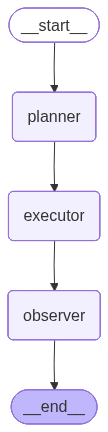

In [2]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## 2. The three-stage `MultiGoal`

Each sub-goal is an ordinary `GoalSpec` with a single boolean condition. The `MultiGoal` wraps them in declaration order and sets `mode="sequential"` so the observer executes them one after another.

In [3]:
goal = product_launch_goal()
print(f"mode          : {goal.mode}")
print(f"sub-goals     : {len(goal.goals)}")
for i, sub in enumerate(goal.goals):
    print(f"  stage {i + 1}      : {dict(sub.conditions)}")

mode          : sequential
sub-goals     : 3
  stage 1      : {'prd_approved': True}
  stage 2      : {'qa_passed': True}
  stage 3      : {'launched': True}


## 3. Running the whole launch

A single `graph.invoke` call drives all three stages. The observer routes between planner and executor as usual, then — when a sub-goal's conditions are satisfied — wipes the plan, resets per-sub-goal accounting, increments `current_subgoal_index`, and re-enters the planner for the next stage.

In [4]:
from langgoap import GoapGraph

graph = GoapGraph(actions)
result = graph.invoke(
    goal=goal,
    world_state={**product_launch_start(), "product_name": "LangGoap SaaS"},
)

print(f"status        : {result['status']}")
print(f"final stage   : {result['current_subgoal_index'] + 1} of {len(goal.goals)}")
print("\nworld state at the end:")
for k, v in sorted(result["world_state"].items()):
    if isinstance(v, str) and len(v) > 80:
        print(f"  {k:<18s} = {v[:80]}...")
    else:
        print(f"  {k:<18s} = {v}")

status        : goal_achieved
final stage   : 3 of 3

world state at the end:
  code_written       = True
  launch_announcement = **FOR IMMEDIATE RELEASE**

**Unlock a World of Communication with LangGoap SaaS:...
  launched           = True
  market_data        = True
  market_research    = **Market Analysis for LangGoap SaaS**

**Product Description:**
LangGoap is a So...
  marketing_content  = ### Marketing Brief for LangGoap SaaS

**Value Proposition:**
LangGoap SaaS revo...
  marketing_ready    = True
  prd_approved       = True
  prd_content        = # Product Requirements Document (PRD) for LangGoap SaaS

## Problem Statement
La...
  product_name       = LangGoap SaaS
  qa_passed          = True


In [5]:
for i, record in enumerate(result["execution_history"]):
    print(f"  step {i + 1:>2d}  {record.action_name}")

  step  1  research_market
  step  2  write_prd
  step  3  implement_features
  step  4  qa_test
  step  5  prepare_marketing
  step  6  announce_launch


## 4. Observability: tracing sub-goal planning isolation

A custom `PlanningTracer` records which sub-goal each plan was built for. In sequential mode, the tracer's `on_plan_start` receives the *effective* `GoalSpec` (not the raw `MultiGoal`), so each stage plans in isolation — later stages are invisible during earlier stages.

In [6]:
from langgoap import NullTracer


class SubgoalTracer(NullTracer):
    """Record which sub-goal each plan was built for and what actions it contains."""

    def __init__(self) -> None:
        self.plans: list[tuple[tuple[str, ...], tuple[str, ...]]] = []
        self._pending_goal: tuple[str, ...] | None = None

    def on_plan_start(self, goal: Any, state: Any, strategy_name: str) -> None:
        self._pending_goal = tuple(sorted(goal.conditions.keys()))

    def on_plan_complete(self, plan: Any, duration_ms: float) -> None:
        assert self._pending_goal is not None
        self.plans.append((self._pending_goal, tuple(plan.action_names)))
        self._pending_goal = None


tracer = SubgoalTracer()
traced_graph = GoapGraph(product_launch_actions(llm), tracer=tracer)
traced_graph.invoke(
    goal=product_launch_goal(),
    world_state={**product_launch_start(), "product_name": "LangGoap SaaS"},
)

for i, (sub_keys, plan) in enumerate(tracer.plans):
    print(f"stage {i + 1}  sub-goal={sub_keys[0]!r}")
    for step in plan:
        print(f"          {step}")

stage 1  sub-goal='prd_approved'
          research_market
          write_prd
stage 2  sub-goal='qa_passed'
          implement_features
          qa_test
stage 3  sub-goal='launched'
          prepare_marketing
          announce_launch


## 5. Shortcut behavior: pre-satisfied stages

Neither `research_market` nor `write_prd` ran — stage 1's observer check saw `prd_approved=True` in the starting state and advanced straight to stage 2. The four actions that did run are the full stage 2 and stage 3 sequences.

In [7]:
start = product_launch_start()
start["prd_approved"] = True  # stage 1 already locked

shortcut_graph = GoapGraph(product_launch_actions(llm))
shortcut = shortcut_graph.invoke(
    goal=product_launch_goal(),
    world_state={**start, "product_name": "LangGoap SaaS"},
)

print("executed actions (stage 1 already locked):")
for r in shortcut["execution_history"]:
    print(f"  {r.action_name}")
assert shortcut["status"] == "goal_achieved"

executed actions (stage 1 already locked):
  implement_features
  qa_test
  prepare_marketing
  announce_launch


## 6. Replanning on action failure

When an action fails mid-stage, the observer detects the deviation and triggers replanning within the same sub-goal. The `max_retries` parameter on `ActionSpec` controls per-action retry attempts before the observer blacklists the action and re-enters the planner.

In [8]:
from langgoap import ActionSpec, GoalPolicy, GoalSpec, MultiGoal

qa_attempts = {"n": 0}


def flaky_qa(ws: dict[str, Any]) -> dict[str, Any]:
    qa_attempts["n"] += 1
    if qa_attempts["n"] == 1:
        raise RuntimeError("transient QA flake")
    return {"qa_passed": True}


# Swap in the flaky action, keep the other five.
flaky_actions = [
    ActionSpec(
        name=a.name,
        preconditions=dict(a.preconditions),
        effects=dict(a.effects),
        cost=a.cost,
        execute=flaky_qa if a.name == "qa_test" else a.execute,
        max_retries=1 if a.name == "qa_test" else 0,
    )
    for a in product_launch_actions(llm)
]

tight_goal = MultiGoal(
    goals=(
        GoalSpec(conditions={"prd_approved": True}, policy=GoalPolicy(max_replans=1)),
        GoalSpec(conditions={"qa_passed": True}, policy=GoalPolicy(max_replans=1)),
        GoalSpec(conditions={"launched": True}, policy=GoalPolicy(max_replans=1)),
    ),
    mode="sequential",
)

recovered = GoapGraph(flaky_actions).invoke(
    goal=tight_goal,
    world_state={**product_launch_start(), "product_name": "LangGoap SaaS"},
)

print(f"status          : {recovered['status']}")
print(f"launched        : {recovered['world_state']['launched']}")
print(f"qa attempts     : {qa_attempts['n']}")
print("\nfull execution history:")
for r in recovered["execution_history"]:
    print(f"  {r.action_name}")

Action 'qa_test' failed: transient QA flake


status          : goal_achieved
launched        : True
qa attempts     : 2

full execution history:
  research_market
  write_prd
  implement_features
  qa_test
  qa_test
  prepare_marketing
  announce_launch


Stage 2's flaky action fired twice: one failure, one recovery. Stage 3 still reached `launched=True` even though its `max_replans=1` budget was never touched. If the budget were cumulative across sub-goals, the moment stage 2 consumed its replan, stage 3 would enter its first plan with `replan_count=1`, and any hiccup at all would terminate the launch.

The per-sub-goal reset lives in `GoapObserver._route` at the sub-goal-advance branch. When the observer emits `goto="planner"` with `replan_reason="subgoal_achieved"`, it also sets `replan_count=0`, `blacklisted_actions=[]`, and `action_failure_counts={}`. The unit regression test `tests/integration/test_multi_goal_loop.py::TestSubgoalAdvanceCommand` pins this exact `Command.update` shape.

## Summary

Six actions. Three sub-goals. One `graph.invoke` call. LangGOAP's `MultiGoal` expresses dependent, staged workflows without asking the user to manually juggle world state between A* invocations.

Key takeaways:

- **`MultiGoal(goals=(...,), mode="sequential")`** chains sub-goals in declaration order.
- The planner resolves the `MultiGoal` wrapper into the *current* sub-goal before running A*, so each stage plans in isolation. Later stages are invisible during an earlier stage.
- Sub-goal effects remain in the world state for the next stage, making hand-off automatic.
- Every sub-goal advance resets `replan_count`, the blacklist, and failure counts so an upstream problem cannot starve a downstream recovery.
- `PlanningTracer.on_plan_start` receives the *effective* `GoalSpec` in sequential mode (not the raw `MultiGoal`), so observability tooling sees a plain goal per stage.

Next steps: compose `MultiGoal` with `StoreExecutionHistory` (notebook 11) to record one `ExecutionRecord` per sub-goal, or pair it with the CSP optimizer (notebooks 4–8) to run constraint satisfaction inside each stage.